In [5]:
import geopandas as gpd
import pandas as pd
from numpy.ma.extras import column_stack

In [4]:
# Read file with county shapefiles
counties = gpd.read_file(
    "/data/raw/tl_2024_us_county.zip"
)

# Limit to Texas
counties = counties[
    counties['STATEFP'] == '48'
]

counties.head()

,STATEFP,COUNTYFP,COUNTYNS,GEOID,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,CBSAFP,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
7,48,327,01383949,48327,0500000US48327,Menard,Menard County,06,H1,G4020,NaN,NaN,NaN,A,2336237980,613559,+30.8852677,-099.8588613,"POLYGON ((-99.7712 30.71079, -99.7824 30.71078..."
11,48,189,01383880,48189,0500000US48189,Hale,Hale County,06,H1,G4020,352,38380,NaN,A,2602109424,246678,+34.0684364,-101.8228879,"POLYGON ((-102.09042 34.31313, -102.0889 34.31..."
13,48,011,01383791,48011,0500000US48011,Armstrong,Armstrong County,06,H1,G4020,108,11100,NaN,A,2354617584,12183672,+34.9641790,-101.3566363,"POLYGON ((-101.62512 35.0007, -101.62509 35.00..."
35,48,057,01383814,48057,0500000US48057,Calhoun,Calhoun County,06,H1,G4020,544,38920,NaN,A,1312947260,1361644522,+28.4417191,-096.5795739,"POLYGON ((-96.64344 28.7121, -96.64322 28.7121..."
38,48,077,01383824,48077,0500000US48077,Clay,Clay County,06,H1,G4020,NaN,48660,NaN,A,2819873723,72504932,+33.7859042,-098.2129174,"POLYGON ((-98.4236 34.03621, -98.42357 34.0391..."


In [8]:
# Create the df with data profiles
df = pd.read_parquet(
    "C:/Users/viole/dev/projects/portfolio/texas-county-dashboard/src/texas_county_dashboards/data/processed/texas_county_analytics.parquet"
)

df.head()

,state,county,GEOID,NAME,population,population_25_plus,less_than_9th_grade,high_school_graduate,bachelors,masters,...,renter_occupied_units,median_home_value,median_gross_rent,average_household_size,bachelors_plus_pct,unemployment_rate,poverty_rate,homeownership_rate,vacancy_rate,percent_with_snap
0,48,001,48001,"Anderson County, Texas",58439,42299,496,11227,4614,1373,...,4863,185300,1041,2.73,15.392799,5.952275,17.364884,72.336310,14.863425,5.409059
1,48,003,48003,"Andrews County, Texas",18610,11259,560,3125,1634,245,...,1470,195700,1305,2.69,17.683631,3.319548,15.592595,78.521333,4.319866,4.787749
2,48,005,48005,"Angelina County, Texas",87275,57523,1327,16177,6488,3173,...,11621,163500,1076,2.60,17.944127,6.387687,15.758971,63.989340,12.835265,6.193068
3,48,007,48007,"Aransas County, Texas",24876,19444,245,4959,4068,1146,...,2900,265400,1128,1.97,28.810944,4.089980,14.242277,76.759096,22.007625,4.305355
4,48,009,48009,"Archer County, Texas",8867,6339,39,1842,1132,362,...,539,189100,770,2.54,25.366777,3.038869,9.173479,84.457901,12.556732,2.560054


### Compare GEOID columns

In [7]:
df.dtypes["GEOID"]

dtype('O')

In [9]:
counties.dtypes["GEOID"]

<StringDtype(storage='python', na_value=nan)>

In [10]:
# convert to string
df["GEOID"] = df["GEOID"].astype(str)
df.dtypes["GEOID"]

<StringDtype(storage='python', na_value=nan)>

In [11]:
# Merge the df and the counties boundary data
county_map = counties.merge(
    df,
    on="GEOID",
    how="left"
)

county_map.head()

,STATEFP,COUNTYFP,COUNTYNS,GEOID,GEOIDFQ,NAME_x,NAMELSAD,LSAD,CLASSFP,MTFCC,...,renter_occupied_units,median_home_value,median_gross_rent,average_household_size,bachelors_plus_pct,unemployment_rate,poverty_rate,homeownership_rate,vacancy_rate,percent_with_snap
0,48,327,01383949,48327,0500000US48327,Menard,Menard County,06,H1,G4020,...,182,108500,729,2.03,23.976222,10.798122,18.858041,80.679406,31.887202,4.398977
1,48,189,01383880,48189,0500000US48189,Hale,Hale County,06,H1,G4020,...,4350,116500,836,2.73,15.314371,5.276918,20.535773,60.540639,17.682198,7.880240
2,48,011,01383791,48011,0500000US48011,Armstrong,Armstrong County,06,H1,G4020,...,152,171500,1021,2.31,27.174750,1.240135,5.194805,80.182529,13.431151,1.427003
3,48,057,01383814,48057,0500000US48057,Calhoun,Calhoun County,06,H1,G4020,...,1971,171200,891,2.26,20.056334,7.374015,7.663675,77.266436,19.966768,6.830079
4,48,077,01383824,48077,0500000US48077,Clay,Clay County,06,H1,G4020,...,687,171500,811,2.43,22.359768,1.951780,8.385542,83.982280,16.928143,2.601239


In [12]:
county_map.isna().sum()

STATEFP               0
COUNTYFP              0
COUNTYNS              0
GEOID                 0
GEOIDFQ               0
                     ..
unemployment_rate     0
poverty_rate          0
homeownership_rate    0
vacancy_rate          0
percent_with_snap     0
Length: 65, dtype: int64

In [13]:
county_map["population"].isna().sum()

np.int64(0)

## Texas Maps

<Axes: >

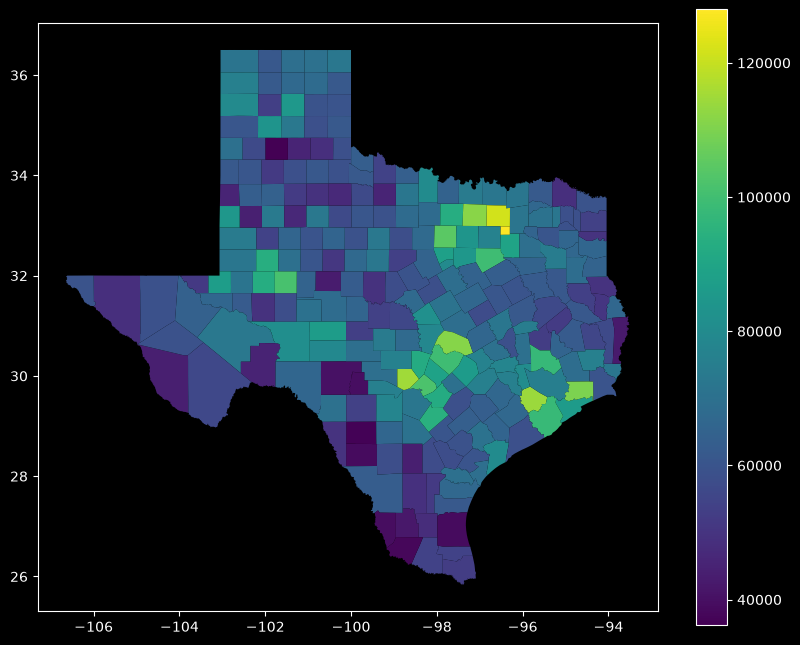

In [14]:
# Income
county_map.plot(
    column="median_household_income",
    legend=True,
    figsize=(10, 8)
)

<Axes: >

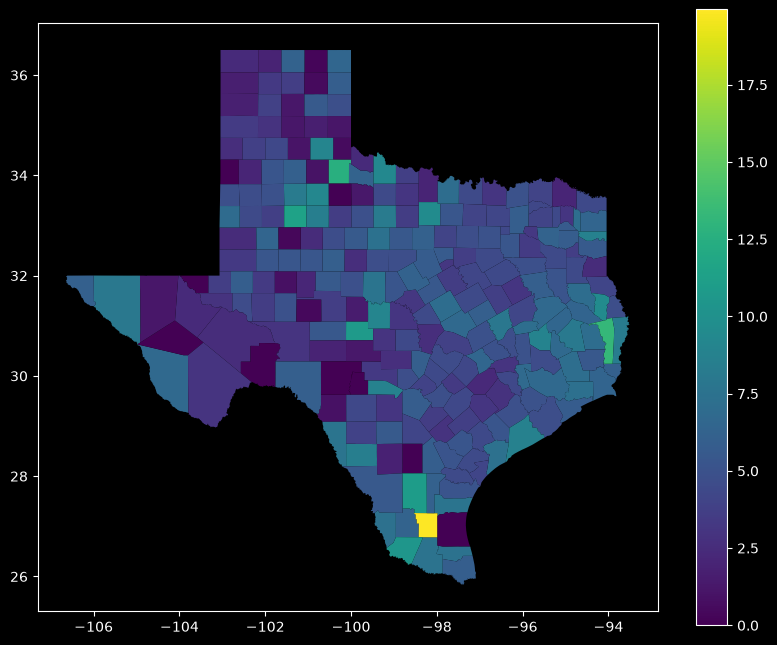

In [15]:
# Unemployment
county_map.plot(
    column="unemployment_rate",
    legend=True,
    figsize=(10, 8)
)